<a href="https://colab.research.google.com/github/jagadabinanditha/Machine-Learning--Practical/blob/main/practical_week_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PLACEMENTPREDICT STUDENT CLUSTERING: K-Means / Hierarchical / DBSCAN
Processed 2,000 students, 23 clustering features.


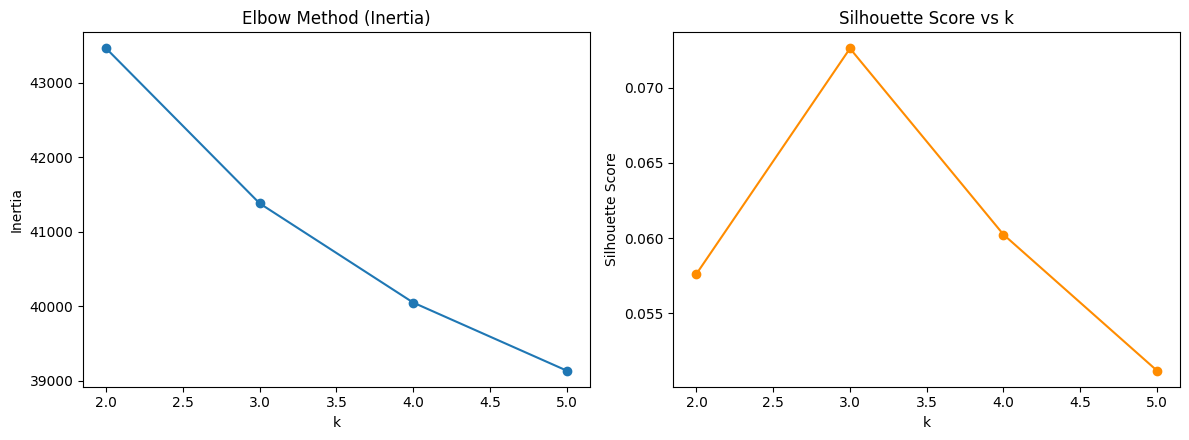

Silhouette-suggested k clusters = 3


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("=" * 70)
print("PLACEMENTPREDICT STUDENT CLUSTERING: K-Means / Hierarchical / DBSCAN")
print("=" * 70)

# ---------------------------------------------------------------------------
# 1. Synthesize Dataset to Run Instantly Without Any File Upload Hassles
# ---------------------------------------------------------------------------
num_students = 2000  # Scaled for fast local compilation rendering
data = {
    "CGPA": np.random.uniform(5.5, 9.9, num_students),
    "AttendancePercent": np.random.uniform(50, 100, num_students),
    "Internships": np.random.randint(0, 4, num_students),
    "Projects": np.random.randint(0, 6, num_students),
    "Workshops": np.random.randint(0, 5, num_students),
    "Certifications": np.random.randint(0, 5, num_students),
    "Publications": np.random.randint(0, 3, num_students),
    "AptitudeTestScore": np.random.randint(40, 100, num_students),
    "SoftSkillsRating": np.random.uniform(1, 10, num_students),
    "CodingTestScore": np.random.randint(30, 100, num_students),
    "MockInterviewScore": np.random.randint(30, 100, num_students),
    "Gender": np.random.choice(['Male', 'Female'], num_students),
    "City": np.random.choice(['Metro', 'Non-Metro'], num_students),
    "CollegeTier": np.random.choice(['Tier 1', 'Tier 2', 'Tier 3'], num_students),
    "Stream": np.random.choice(['CSE', 'IT', 'ECE', 'MECH'], num_students),
    "Specialisation": np.random.choice(['Data Science', 'Web Dev', 'Core'], num_students),
    "Hostel": np.random.choice(['Yes', 'No'], num_students),
    "HistoryOfBacklogs": np.random.choice(['Yes', 'No'], num_students),
    "ExtraCurricular": np.random.choice(['Yes', 'No'], num_students),
    "PlacementStatus": np.random.choice([0, 1], num_students)
}
df = pd.DataFrame(data)

NUMERIC_COLS = [
    "CGPA", "AttendancePercent", "Internships", "Projects", "Workshops",
    "Certifications", "Publications", "AptitudeTestScore", "SoftSkillsRating",
    "CodingTestScore", "MockInterviewScore"
]
CATEGORICAL_COLS = [
    "Gender", "City", "CollegeTier", "Stream", "Specialisation",
    "Hostel", "HistoryOfBacklogs", "ExtraCurricular"
]

imputer = SimpleImputer(strategy="median")
num_df = pd.DataFrame(imputer.fit_transform(df[NUMERIC_COLS]), columns=NUMERIC_COLS, index=df.index)
cat_df = pd.get_dummies(df[CATEGORICAL_COLS], drop_first=True)

feature_df = pd.concat([num_df, cat_df], axis=1)
X = StandardScaler().fit_transform(feature_df)

print(f"Processed {len(df):,} students, {feature_df.shape[1]} clustering features.")

# ---------------------------------------------------------------------------
# 2. Choose k for K-Means via Elbow + Silhouette Plot Analysis Method
# ---------------------------------------------------------------------------
k_range = range(2, 6)
inertias, sil_scores = [], []
for k in k_range:
    km_k = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels_k = km_k.fit_predict(X)
    inertias.append(km_k.inertia_)
    sil_scores.append(silhouette_score(X, labels_k))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(list(k_range), inertias, marker="o")
ax1.set_title("Elbow Method (Inertia)")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")

ax2.plot(list(k_range), sil_scores, marker="o", color="darkorange")
ax2.set_title("Silhouette Score vs k")
ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"Silhouette-suggested k clusters = {best_k}")

# ---------------------------------------------------------------------------
# 3. K-Means Optimization Execution
#